# Keypoint Model Comparison

This notebook benchmarks trained keypoint models saved in `models/keypoint` against the landmark dataset built from MediaPipe hand gestures.


*ENSURE all models are trained using the same dataset*

This run was trained and tested on 60K dataset of 10 gestures
* 0 - open - ✋
* 1 - close - ✊
* 2 - pointing - 👆
* 3 - ok - 👌
* 4 - peace ✌️
* 5 - metal 🤘
* 6 - thumb 👍
* 7 - pinch_all
* 8 - pinch_small
* 9 - love 🤟


In [19]:
import csv
import datetime
import re
import time
from itertools import count
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import joblib
import tensorflow as tf

from scipy.stats import chi2
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    top_k_accuracy_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

np.set_printoptions(linewidth=140, suppress=True)
pd.set_option("display.max_colwidth", None)

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "data").is_dir() and (candidate / "models").is_dir():
            return candidate
    raise RuntimeError("Could not locate the project root (data/ and models/ folders not found).")

REPO_ROOT = find_repo_root(Path.cwd())
DATA_FILE = REPO_ROOT / "data" / "keypoint_10gestures_60k.csv"
LABELS_FILE = REPO_ROOT / "data" / "keypoint_labels10gestures_60k.csv"
MODEL_DIR = REPO_ROOT / "models" / "keypoint"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

TOP_K = 3
TOP_K_KEY = f"top_{TOP_K}_accuracy"
NOISE_STD = 0.015
RANDOM_SEED = 42
GESTURE_GROUPS = {
    "Cluster A": [3, 7, 8, 9],  # OK, Pinch All, Pinch Small, Love
    "Cluster B": [2, 4, 5, 6],  # Pointing, Peace, Metal, Thumb
}

# Optional overrides for training time measurements (seconds)
TRAINING_TIME_OVERRIDES = {
    # "joblib::keypoint_classifier_LogisticRegression.joblib": 12.4,
    # "tflite::keypoint_classifier.tflite": 480.0,
}

TRAIN_MODELS = True
TEST_SIZE = 0.3

TRAINED_JOBLIB_MODELS = []
TRAINED_TFLITE_MODELS = []
TRAINING_RUN_RECORDS = []
ARTIFACT_COUNTER = count()

rng = np.random.default_rng(RANDOM_SEED)

JOBLIB_MODELS = []
TFLITE_MODELS = []

print(f"TensorFlow version: {tf.__version__}")
print(f"Repo root: {REPO_ROOT}")
print(f"Dataset: {DATA_FILE}")
print(f"Models directory: {MODEL_DIR}")
print(f"Training enabled: {TRAIN_MODELS}")


TensorFlow version: 2.19.1
Repo root: c:\Users\brian\Documents\GitHub\mediapipe-hand-recognition
Dataset: c:\Users\brian\Documents\GitHub\mediapipe-hand-recognition\data\keypoint_10gestures_60k.csv
Models directory: c:\Users\brian\Documents\GitHub\mediapipe-hand-recognition\models\keypoint
Training enabled: True


In [20]:
def load_label_map(path: Path):
    mapping = {}
    with path.open(encoding="utf-8-sig") as f:
        reader = csv.reader(f)
        for idx, row in enumerate(reader):
            if not row:
                continue
            raw = row[0].strip()
            digits = "".join(ch for ch in raw if ch.isdigit())
            label_id = int(digits) if digits else idx
            label_name = raw[: len(raw) - len(digits)] or raw
            mapping[label_id] = label_name
    return mapping

label_map = load_label_map(LABELS_FILE)
label_ids_sorted = sorted(label_map.keys())
label_names_sorted = [label_map[i] for i in label_ids_sorted]

df = pd.read_csv(DATA_FILE, header=None)
print(f"Dataset shape: {df.shape} (rows x columns)")
display(df.head())

X = df.iloc[:, 1:].to_numpy(dtype=np.float32)
y = df.iloc[:, 0].astype(int).to_numpy()

X_noise = (X + rng.normal(loc=0.0, scale=NOISE_STD, size=X.shape)).astype(np.float32)

print(f"Feature matrix: {X.shape}, Labels: {y.shape}, Unique classes: {sorted(np.unique(y))}")
print(f"Noise std applied to landmarks: {NOISE_STD}")


Dataset shape: (60559, 43) (rows x columns)


,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0,0.0,0.0,0.200787,-0.051181,0.366142,-0.181102,0.484252,-0.307087,0.594488,...,0.039370,-0.976378,-0.074803,-0.429134,-0.145669,-0.578740,-0.185039,-0.685039,-0.220472,-0.787402
1,0,0.0,0.0,0.206349,-0.043651,0.376984,-0.162698,0.507937,-0.273810,0.615079,...,0.047619,-0.980159,-0.079365,-0.428571,-0.142857,-0.583333,-0.182540,-0.690476,-0.210317,-0.793651
2,0,0.0,0.0,0.202381,-0.043651,0.373016,-0.162698,0.500000,-0.277778,0.607143,...,0.039683,-0.980159,-0.083333,-0.428571,-0.146825,-0.579365,-0.186508,-0.686508,-0.214286,-0.789683
3,0,0.0,0.0,0.207171,-0.039841,0.382470,-0.159363,0.509960,-0.274900,0.617530,...,0.051793,-0.980080,-0.079681,-0.426295,-0.143426,-0.581673,-0.183267,-0.689243,-0.211155,-0.792829
4,0,0.0,0.0,0.206349,-0.039683,0.380952,-0.162698,0.507937,-0.281746,0.615079,...,0.051587,-0.980159,-0.079365,-0.428571,-0.142857,-0.583333,-0.178571,-0.690476,-0.210317,-0.793651


Feature matrix: (60559, 42), Labels: (60559,), Unique classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Noise std applied to landmarks: 0.015


In [21]:
NUM_FEATURES = X.shape[1]
FEATURES_PER_LANDMARK = 2
NUM_LANDMARKS = NUM_FEATURES // FEATURES_PER_LANDMARK
NUM_CLASSES = len(label_ids_sorted)

X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y,
)

print(f"Train split: {X_train_split.shape}, Validation split: {X_val_split.shape}")
print(f"Class distribution (train): {np.bincount(y_train_split, minlength=NUM_CLASSES)}")
print(f"Class distribution (val):   {np.bincount(y_val_split, minlength=NUM_CLASSES)}")


Train split: (42391, 42), Validation split: (18168, 42)
Class distribution (train): [4177 4349 4232 4381 4394 4228 3979 4224 4203 4224]
Class distribution (val):   [1790 1864 1814 1877 1884 1812 1705 1811 1801 1810]


## Unified Training Pipelines


In [22]:
def slugify_name(name: str) -> str:
    slug = re.sub(r"[^0-9a-zA-Z]+", "_", name).strip("_").lower()
    return slug or "model"

def next_artifact_suffix() -> str:
    return f"{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}_{next(ARTIFACT_COUNTER):02d}"

def log_training_record(model_name, artifact_type, artifact_path, train_time, metrics=None):
    record = {
        "model_name": model_name,
        "artifact_type": artifact_type,
        "artifact_path": str(artifact_path),
        "train_time_s": float(train_time),
    }
    if metrics:
        record.update(metrics)
    TRAINING_RUN_RECORDS.append(record)


def register_joblib_model(display_name, alias, estimator, train_time, metrics=None):
    slug = slugify_name(alias or display_name)
    suffix = next_artifact_suffix()
    path = MODEL_DIR / f"keypoint_classifier_{slug}_{suffix}.joblib"
    joblib.dump(estimator, path)
    TRAINED_JOBLIB_MODELS.append(path)
    TRAINING_TIME_OVERRIDES[f"joblib::{path.name}"] = float(train_time)
    log_training_record(display_name, "joblib", path, train_time, metrics)
    return path


def register_tflite_model(display_name, alias, keras_model, train_time, metrics=None, quantize=True):
    slug = slugify_name(alias or display_name)
    suffix = next_artifact_suffix()
    keras_path = MODEL_DIR / f"keypoint_classifier_{slug}_{suffix}.keras"
    keras_model.save(keras_path, include_optimizer=False)

    converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)
    if quantize:
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
    tflite_buffer = converter.convert()

    tflite_path = MODEL_DIR / f"keypoint_classifier_{slug}_{suffix}.tflite"
    with tflite_path.open("wb") as f:
        f.write(tflite_buffer)
    TRAINED_TFLITE_MODELS.append(tflite_path)
    TRAINING_TIME_OVERRIDES[f"tflite::{tflite_path.name}"] = float(train_time)
    log_training_record(display_name, "tflite", tflite_path, train_time, metrics)
    return keras_path, tflite_path


def evaluate_split_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    return acc, macro_f1


def reset_tf_session():
    tf.keras.backend.clear_session()


In [23]:
def train_classical_baselines(X_train, y_train, X_val, y_val):
    print("Training classical ML baselines (KNN only)...")
    models = {
        "KNeighbors": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier(
                n_neighbors=5,
                weights="distance",
                metric="minkowski",
            )),
        ]),
    }

    artifacts = []
    for name, estimator in models.items():
        start = time.perf_counter()
        estimator.fit(X_train, y_train)
        duration = time.perf_counter() - start
        y_pred = estimator.predict(X_val)
        acc, macro_f1 = evaluate_split_metrics(y_val, y_pred)
        metrics = {"val_accuracy": acc, "val_macro_f1": macro_f1}
        path = register_joblib_model(f"Baseline::{name}", name, estimator, duration, metrics)
        print(f"  {name:15s} | acc={acc:.4f} macro F1={macro_f1:.4f} | saved->{path.name}")
        artifacts.append((name, path))
    return artifacts


In [24]:
def build_mlp_baseline(input_dim, num_classes):
    return tf.keras.Sequential([
        tf.keras.layers.Input((input_dim,)),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(20, activation="relu"),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(10, activation="relu"),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(num_classes, activation="softmax"),
    ], name="mlp_keypoint_classifier")


def train_mlp_classifier(X_train, y_train, X_val, y_val):
    print("Training MLP baseline (Keras)...")
    reset_tf_session()
    model = build_mlp_baseline(X_train.shape[1], NUM_CLASSES)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    callbacks = [
        tf.keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True, verbose=1)
    ]
    start = time.perf_counter()
    model.fit(
        X_train.astype(np.float32),
        y_train,
        epochs=200,
        batch_size=128,
        validation_data=(X_val.astype(np.float32), y_val),
        callbacks=callbacks,
        verbose=1,
    )
    duration = time.perf_counter() - start
    preds = np.argmax(model.predict(X_val.astype(np.float32), verbose=0), axis=1)
    acc, macro_f1 = evaluate_split_metrics(y_val, preds)
    metrics = {"val_accuracy": acc, "val_macro_f1": macro_f1}
    keras_path, tflite_path = register_tflite_model("MLP", "mlp", model, duration, metrics)
    print(f"  MLP validation accuracy={acc:.4f}, macro F1={macro_f1:.4f} | saved→{tflite_path.name}")
    return keras_path, tflite_path


In [25]:
from tensorflow.keras import layers, regularizers

def build_1dcn_classifier(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv1D(64, kernel_size=3, padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv1D(128, kernel_size=3, padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling1D(pool_size=2),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Conv1D(128, kernel_size=3, padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv1D(256, kernel_size=3, padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.25),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ], name="cnn_1d_keypoint_classifier")
    return model

def train_1dcn_classifier(X_train, y_train, X_val, y_val):
    print("Training 1DCN classifier...")
    reset_tf_session()

    # Reshape for 1DCN: (N, 21, 2)
    # Ensure data is float32
    X_train_reshaped = X_train.astype(np.float32).reshape(-1, 21, 2)
    X_val_reshaped = X_val.astype(np.float32).reshape(-1, 21, 2)

    model = build_1dcn_classifier((21, 2), NUM_CLASSES)

    # Optimizer from the 1DCN notebook
    lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
        initial_learning_rate=3e-4,
        first_decay_steps=2000,
    )
    optimizer = tf.keras.optimizers.AdamW(
        learning_rate=lr_schedule,
        weight_decay=1e-4
    )

    model.compile(optimizer=optimizer,
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])

    callbacks = [
        tf.keras.callbacks.EarlyStopping(patience=25, restore_best_weights=True, verbose=1)
    ]

    start = time.perf_counter()
    model.fit(
        X_train_reshaped,
        y_train,
        epochs=300,
        batch_size=128,
        validation_data=(X_val_reshaped, y_val),
        callbacks=callbacks,
        verbose=1,
    )
    duration = time.perf_counter() - start

    preds = np.argmax(model.predict(X_val_reshaped, verbose=0), axis=1)
    acc, macro_f1 = evaluate_split_metrics(y_val, preds)
    metrics = {"val_accuracy": acc, "val_macro_f1": macro_f1}

    _, tflite_path = register_tflite_model("1DCN", "cnn_1d", model, duration, metrics)
    print(f"  1DCN validation accuracy={acc:.4f}, macro F1={macro_f1:.4f} | saved->{tflite_path.name}")
    return tflite_path


In [26]:
def build_transformer_classifier(num_joints, joint_dim, num_classes,
                                 d_model=64, num_heads=4, ff_multiplier=2,
                                 num_layers=2, dropout_rate=0.1):
    inputs = tf.keras.Input(shape=(num_joints * joint_dim,))
    x = tf.keras.layers.Reshape((num_joints, joint_dim))(inputs)
    x = tf.keras.layers.Dense(d_model)(x)

    for _ in range(num_layers):
        attn = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
        x = tf.keras.layers.Add()([x, attn])
        x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)

        ff = tf.keras.layers.Dense(d_model * ff_multiplier, activation="relu")(x)
        ff = tf.keras.layers.Dense(d_model)(ff)
        ff = tf.keras.layers.Dropout(dropout_rate)(ff)
        x = tf.keras.layers.Add()([x, ff])
        x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)

    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dropout(dropout_rate)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)
    return tf.keras.Model(inputs=inputs, outputs=outputs, name="transformer_self_attention")


def train_self_attention_transformer(X_train, y_train, X_val, y_val):
    print("Training Transformer self-attention model...")
    reset_tf_session()
    model = build_transformer_classifier(NUM_LANDMARKS, FEATURES_PER_LANDMARK, NUM_CLASSES)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    callbacks = [tf.keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True, verbose=1)]
    start = time.perf_counter()
    model.fit(
        X_train.astype(np.float32), y_train,
        epochs=170,
        batch_size=128,
        validation_data=(X_val.astype(np.float32), y_val),
        callbacks=callbacks,
        verbose=1,
    )
    duration = time.perf_counter() - start
    preds = np.argmax(model.predict(X_val.astype(np.float32), verbose=0), axis=1)
    acc, macro_f1 = evaluate_split_metrics(y_val, preds)
    metrics = {"val_accuracy": acc, "val_macro_f1": macro_f1}
    _, tflite_path = register_tflite_model("TransformerSelfAttention", "transformer_self_attention", model, duration, metrics)
    print(f"  Transformer validation accuracy={acc:.4f}, macro F1={macro_f1:.4f} | saved→{tflite_path.name}")
    return tflite_path


In [27]:
if TRAIN_MODELS:
    # 1. KNN
    train_classical_baselines(X_train_split, y_train_split, X_val_split, y_val_split)

    # 2. MLP
    train_mlp_classifier(X_train_split, y_train_split, X_val_split, y_val_split)

    # 3. Transformer (Self-Attention)
    train_self_attention_transformer(X_train_split, y_train_split, X_val_split, y_val_split)

    # 4. 1DCN
    train_1dcn_classifier(X_train_split, y_train_split, X_val_split, y_val_split)


Training classical ML baselines (KNN only)...
  KNeighbors      | acc=0.9759 macro F1=0.9760 | saved->keypoint_classifier_kneighbors_20251203_171329_00.joblib
Training MLP baseline (Keras)...
Epoch 1/200
332/332 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.1473 - loss: 2.2556 - val_accuracy: 0.2739 - val_loss: 2.0631
Epoch 2/200
332/332 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2160 - loss: 2.0675 - val_accuracy: 0.4060 - val_loss: 1.8090
Epoch 3/200
332/332 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2651 - loss: 1.9417 - val_accuracy: 0.4908 - val_loss: 1.6498
Epoch 4/200
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3033 - loss: 1.8478 - val_accuracy: 0.5217 - val_loss: 1.5483
Epoch 5/200
332/332 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.3300 - loss: 1.7842 - val_accuracy: 0.5285 - val_loss: 1.4721
Epoch 6/200
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3412 - loss: 1.7423 - val_accuracy: 0.5132 - val_loss: 1.4150
Epoch 7/200
332/332 ━━━━━━━━━━━━━━

INFO:tensorflow:Assets written to: C:\Users\brian\AppData\Local\Temp\tmpz4nhsegz\assets


Saved artifact at 'C:\Users\brian\AppData\Local\Temp\tmpz4nhsegz'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 42), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  2227203406928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2227267313808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2227267314576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2227267320336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2227267317840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2227267314192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  MLP validation accuracy=0.6095, macro F1=0.5932 | saved→keypoint_classifier_mlp_20251203_171400_01.tflite
Training Transformer self-attention model...
Epoch 1/170
332/332 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.2925 - loss: 1.9147 - val_accuracy: 0.4474 - val_loss: 1.5253
Epo

INFO:tensorflow:Assets written to: C:\Users\brian\AppData\Local\Temp\tmpvccv3jeq\assets


Saved artifact at 'C:\Users\brian\AppData\Local\Temp\tmpvccv3jeq'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 42), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  2227202115536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2227203405392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2227267314768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2227267313616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2227267319952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2227267320144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2227267318992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2227267319760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2227267311696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2227267315728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2227267316496

INFO:tensorflow:Assets written to: C:\Users\brian\AppData\Local\Temp\tmpm6pg9_8g\assets


Saved artifact at 'C:\Users\brian\AppData\Local\Temp\tmpm6pg9_8g'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 21, 2), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  2227295893072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2227295894992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2227295895376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2227295893840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2227295891728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2227295890960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2227295891920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2227295895184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2227295894608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2227295892496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2227295883

In [28]:
if TRAINING_RUN_RECORDS:
    training_df = pd.DataFrame(TRAINING_RUN_RECORDS)
    display(training_df.sort_values(by=["val_macro_f1", "val_accuracy"], ascending=False, na_position="last"))
else:
    print("No new training records captured in this session.")


,model_name,artifact_type,artifact_path,train_time_s,val_accuracy,val_macro_f1
3,1DCN,tflite,c:\Users\brian\Documents\GitHub\mediapipe-hand-recognition\models\keypoint\keypoint_classifier_cnn_1d_20251203_180356_03.tflite,664.219499,0.991469,0.991505
0,Baseline::KNeighbors,joblib,c:\Users\brian\Documents\GitHub\mediapipe-hand-recognition\models\keypoint\keypoint_classifier_kneighbors_20251203_171329_00.joblib,0.038819,0.975947,0.975991
2,TransformerSelfAttention,tflite,c:\Users\brian\Documents\GitHub\mediapipe-hand-recognition\models\keypoint\keypoint_classifier_transformer_self_attention_20251203_175246_02.tflite,2320.243386,0.974240,0.974375
1,MLP,tflite,c:\Users\brian\Documents\GitHub\mediapipe-hand-recognition\models\keypoint\keypoint_classifier_mlp_20251203_171400_01.tflite,28.132532,0.609478,0.593233


In [29]:
if TRAINED_JOBLIB_MODELS or TRAINED_TFLITE_MODELS:
    JOBLIB_MODELS = TRAINED_JOBLIB_MODELS
    TFLITE_MODELS = TRAINED_TFLITE_MODELS
else:
    JOBLIB_MODELS = sorted(MODEL_DIR.glob("*.joblib"))
    TFLITE_MODELS = sorted(MODEL_DIR.glob("*.tflite"))

print(f"Detected {len(JOBLIB_MODELS)} joblib models and {len(TFLITE_MODELS)} TFLite models for evaluation.")


Detected 1 joblib models and 3 TFLite models for evaluation.


In [30]:
def describe_label(label_id):
    return f"{label_id}: {label_map.get(label_id, str(label_id))}"

def format_labels(label_ids):
    return [describe_label(idx) for idx in label_ids]

def compute_custom_metrics(y_true, y_pred, similar_group):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    relaxed_correct = []
    for t, p in zip(y_true, y_pred):
        if t in similar_group:
            relaxed_correct.append(p in similar_group)
        else:
            relaxed_correct.append(p == t)
    relaxed_accuracy = float(np.mean(relaxed_correct))
    return relaxed_accuracy

def mcnemars_test(y_true, y_pred_a, y_pred_b):
    y_true = np.asarray(y_true)
    y_pred_a = np.asarray(y_pred_a)
    y_pred_b = np.asarray(y_pred_b)

    correct_a = y_pred_a == y_true
    correct_b = y_pred_b == y_true

    b = np.sum(correct_a & ~correct_b)
    c = np.sum(~correct_a & correct_b)
    n = b + c
    if n == 0:
        return np.nan, np.nan, b, c

    chi2_stat = (abs(b - c) - 1) ** 2 / n
    p_value = chi2.sf(chi2_stat, df=1)
    return chi2_stat, p_value, b, c

def plot_confusion_matrix(cm, label_strings, title="Confusion Matrix"):
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(label_strings)))
    ax.set_yticks(range(len(label_strings)))
    ax.set_xticklabels(label_strings, rotation=45, ha="right")
    ax.set_yticklabels(label_strings)
    ax.set_ylabel("True label")
    ax.set_xlabel("Predicted label")
    ax.set_title(title)

    thresh = cm.max() / 2.0 if cm.any() else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center",
                color="white" if cm[i, j] > thresh else "black",
            )
    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    plt.show()

def plot_two_confusion_matrices(cm_a, labels_a, name_a, cm_b, labels_b, name_b):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, cm, labels, title in zip(
        axes,
        [cm_a, cm_b],
        [labels_a, labels_b],
        [name_a, name_b],
    ):
        im = ax.imshow(cm, cmap="Blues")
        ax.set_xticks(range(len(labels)))
        ax.set_yticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=45, ha="right")
        ax.set_yticklabels(labels)
        ax.set_ylabel("True label")
        ax.set_xlabel("Predicted label")
        ax.set_title(title)
        thresh = cm.max() / 2.0 if cm.any() else 0
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(
                    j,
                    i,
                    cm[i, j],
                    ha="center",
                    va="center",
                    color="white" if cm[i, j] > thresh else "black",
                )
    fig.colorbar(im, ax=axes.ravel().tolist())
    fig.tight_layout()
    plt.show()

def estimate_parameter_count(model):
    seen = set()
    total = 0
    stack = [model]
    while stack:
        obj = stack.pop()
        if obj is None:
            continue
        obj_id = id(obj)
        if obj_id in seen:
            continue
        seen.add(obj_id)

        if isinstance(obj, np.ndarray):
            total += obj.size
            continue
        if isinstance(obj, (list, tuple, set)):
            stack.extend(obj)
            continue
        if isinstance(obj, dict):
            stack.extend(obj.values())
            continue

        for attr in (
            "coef_",
            "intercept_",
            "support_vectors_",
            "dual_coef_",
            "rho_",
            "feature_importances_",
            "estimators_",
            "tree_",
            "value",
        ):
            if hasattr(obj, attr):
                stack.append(getattr(obj, attr))

        if hasattr(obj, "__dict__"):
            stack.extend(obj.__dict__.values())
    return int(total) if total else np.nan

def measure_joblib_training_time(model, X_train, y_train):
    try:
        estimator = clone(model)
    except Exception:
        return np.nan, "clone_failed"

    start = time.perf_counter()
    try:
        estimator.fit(X_train, y_train)
    except Exception:
        return np.nan, "fit_failed"
    elapsed = time.perf_counter() - start
    return float(elapsed), "measured_fit"


In [31]:
def safe_top_k_accuracy(y_true, score_matrix, score_labels, k):
    if score_matrix is None or score_labels is None:
        return np.nan
    score_labels = np.asarray(score_labels)
    if score_matrix.shape[1] != len(score_labels):
        return np.nan
    y_true = np.asarray(y_true)
    mask = np.isin(y_true, score_labels)
    if not np.any(mask):
        return np.nan
    filtered_scores = score_matrix[mask]
    filtered_true = y_true[mask]
    return top_k_accuracy_score(filtered_true, filtered_scores, k=k, labels=score_labels)


def get_joblib_scores(model, X_data, y_true, labels, top_k):
    start = time.perf_counter()
    y_pred = model.predict(X_data)
    elapsed = time.perf_counter() - start
    latency_ms = (elapsed / len(X_data)) * 1000.0
    samples_per_second = len(X_data) / elapsed if elapsed > 0 else np.inf

    y_proba = None
    proba_labels = None
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_data)
        proba_labels = getattr(model, "classes_", None)
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X_data)
        scores = np.asarray(scores)
        if scores.ndim == 1:
            scores = np.vstack([-scores, scores]).T
        exp_scores = np.exp(scores - scores.max(axis=1, keepdims=True))
        y_proba = exp_scores / exp_scores.sum(axis=1, keepdims=True)
        proba_labels = getattr(model, "classes_", None)

    topk_acc = safe_top_k_accuracy(y_true, y_proba, proba_labels, top_k)
    return y_pred, y_proba, topk_acc, latency_ms, samples_per_second


def evaluate_joblib_model(model_path, X_eval, X_eval_noise, y_eval):
    name = f"joblib::{model_path.name}"
    print("")
    print(f"Evaluating {name}")
    model = joblib.load(model_path)

    labels = np.array(sorted(np.unique(y_eval)))
    label_strings = format_labels(labels)

    y_pred, y_proba, topk_acc, latency_ms, sps = get_joblib_scores(
        model, X_eval, y_eval, labels, TOP_K
    )
    y_pred_noise, _, _, _, _ = get_joblib_scores(
        model, X_eval_noise, y_eval, labels, TOP_K
    )

    acc = accuracy_score(y_eval, y_pred)
    macro_f1 = f1_score(y_eval, y_pred, average="macro")
    prec, rec, f1_per_class, support = precision_recall_fscore_support(
        y_eval, y_pred, labels=labels, zero_division=0
    )
    cls_report = classification_report(
        y_eval,
        y_pred,
        labels=labels,
        target_names=label_strings,
        digits=4,
        zero_division=0,
    )
    cm = confusion_matrix(y_eval, y_pred, labels=labels)

    acc_noise = accuracy_score(y_eval, y_pred_noise)
    macro_f1_noise = f1_score(y_eval, y_pred_noise, average="macro")

    group_metrics = {}
    for group_name, group_ids in GESTURE_GROUPS.items():
        relaxed_acc = compute_custom_metrics(y_eval, y_pred, group_ids)
        group_metrics[f"relaxed_acc_{group_name}"] = relaxed_acc

    model_disk_mb = model_path.stat().st_size / (1024**2)
    param_count = estimate_parameter_count(model)

    training_time_s, training_time_source = measure_joblib_training_time(model, X, y)
    if np.isnan(training_time_s):
        training_time_s = TRAINING_TIME_OVERRIDES.get(name, np.nan)
        if not np.isnan(training_time_s):
            training_time_source = "override"

    result = {
        "model_name": name,
        "model_type": "joblib",
        "y_true": y_eval,
        "y_pred": y_pred,
        "y_pred_noise": y_pred_noise,
        "y_proba": y_proba,
        "labels": labels,
        "label_strings": label_strings,
        "cm": cm,
        "classification_report": cls_report,
        "model_disk_mb": model_disk_mb,
        "model_parameter_count": param_count,
        "training_time_s": training_time_s,
        "training_time_source": training_time_source,
        "latency_ms_per_sample": latency_ms,
        "samples_per_second": sps,
        "accuracy": acc,
        TOP_K_KEY: topk_acc,
        "macro_f1": macro_f1,
        "per_class_precision": prec,
        "per_class_recall": rec,
        "per_class_f1": f1_per_class,
        "support": support,
        "accuracy_with_noise": acc_noise,
        "macro_f1_with_noise": macro_f1_noise,
        **group_metrics,
    }

    topk_display = "N/A" if np.isnan(topk_acc) else f"{topk_acc:.4f}"
    param_display = "N/A" if np.isnan(param_count) else f"{int(param_count):,}"

    print(f"  Accuracy={acc:.4f} | Macro F1={macro_f1:.4f} | Top-{TOP_K} Acc={topk_display}")
    print(f"  Latency={latency_ms:.4f} ms/sample | Speed={sps:.2f} samples/s")
    print(f"  Disk size={model_disk_mb:.3f} MB | Parameters~{param_display}")
    print(f"  Noise ({NOISE_STD} sigma) -> acc={acc_noise:.4f}, macro F1={macro_f1_noise:.4f}")
    for group_name in GESTURE_GROUPS:
        print(f"  Relaxed Acc ({group_name})={group_metrics[f'relaxed_acc_{group_name}']:.4f}")

    return name, result


In [32]:
def evaluate_tflite_model(model_path, X_eval, X_eval_noise, y_eval):
    name = f"tflite::{model_path.name}"
    print("")
    print(f"Evaluating {name}")
    interpreter = tf.lite.Interpreter(model_path=str(model_path))
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]
    input_index = input_details["index"]
    output_index = output_details["index"]
    input_shape = input_details["shape"]
    input_dtype = input_details["dtype"]

    def reshape_if_needed(X_data):
        if len(input_shape) == 3:
            n_steps = input_shape[1]
            n_channels = input_shape[2]
            expected_features = n_steps * n_channels
            if X_data.shape[1] == expected_features:
                return X_data.reshape(-1, n_steps, n_channels)
        return X_data

    def run_inference(X_data):
        preds = []
        outputs = []
        start = time.perf_counter()
        X_reshaped = reshape_if_needed(X_data)
        for row in X_reshaped:
            tensor = np.expand_dims(row, axis=0).astype(input_dtype)
            interpreter.set_tensor(input_index, tensor)
            interpreter.invoke()
            out = interpreter.get_tensor(output_index)
            outputs.append(out[0])
            preds.append(int(np.argmax(out)))
        elapsed = time.perf_counter() - start
        latency_ms = (elapsed / len(X_data)) * 1000.0
        samples_per_second = len(X_data) / elapsed if elapsed > 0 else np.inf
        outputs = np.asarray(outputs, dtype=np.float32)
        exp_scores = np.exp(outputs - outputs.max(axis=1, keepdims=True))
        probs = exp_scores / exp_scores.sum(axis=1, keepdims=True)
        return np.array(preds), probs, latency_ms, samples_per_second

    y_pred, y_proba, latency_ms, sps = run_inference(X_eval)
    y_pred_noise, _, _, _ = run_inference(X_eval_noise)

    labels = np.array(sorted(np.unique(y_eval)))
    label_strings = format_labels(labels)

    acc = accuracy_score(y_eval, y_pred)
    macro_f1 = f1_score(y_eval, y_pred, average="macro")
    prec, rec, f1_per_class, support = precision_recall_fscore_support(
        y_eval, y_pred, labels=labels, zero_division=0
    )
    cls_report = classification_report(
        y_eval,
        y_pred,
        labels=labels,
        target_names=label_strings,
        digits=4,
        zero_division=0,
    )
    cm = confusion_matrix(y_eval, y_pred, labels=labels)

    acc_noise = accuracy_score(y_eval, y_pred_noise)
    macro_f1_noise = f1_score(y_eval, y_pred_noise, average="macro")

    group_metrics = {}
    for group_name, group_ids in GESTURE_GROUPS.items():
        relaxed_acc = compute_custom_metrics(y_eval, y_pred, group_ids)
        group_metrics[f"relaxed_acc_{group_name}"] = relaxed_acc

    topk_acc = safe_top_k_accuracy(y_eval, y_proba, labels, TOP_K)
    model_disk_mb = model_path.stat().st_size / (1024**2)
    param_count = np.nan
    training_time_s = TRAINING_TIME_OVERRIDES.get(name, np.nan)
    training_time_source = "override" if name in TRAINING_TIME_OVERRIDES else "unknown"

    result = {
        "model_name": name,
        "model_type": "tflite",
        "y_true": y_eval,
        "y_pred": y_pred,
        "y_pred_noise": y_pred_noise,
        "y_proba": y_proba,
        "labels": labels,
        "label_strings": label_strings,
        "cm": cm,
        "classification_report": cls_report,
        "model_disk_mb": model_disk_mb,
        "model_parameter_count": param_count,
        "training_time_s": training_time_s,
        "training_time_source": training_time_source,
        "latency_ms_per_sample": latency_ms,
        "samples_per_second": sps,
        "accuracy": acc,
        TOP_K_KEY: topk_acc,
        "macro_f1": macro_f1,
        "per_class_precision": prec,
        "per_class_recall": rec,
        "per_class_f1": f1_per_class,
        "support": support,
        "accuracy_with_noise": acc_noise,
        "macro_f1_with_noise": macro_f1_noise,
        **group_metrics,
    }

    topk_display = "N/A" if np.isnan(topk_acc) else f"{topk_acc:.4f}"

    print(f"  Accuracy={acc:.4f} | Macro F1={macro_f1:.4f} | Top-{TOP_K} Acc={topk_display}")
    print(f"  Latency={latency_ms:.4f} ms/sample | Speed={sps:.2f} samples/s")
    print(f"  Disk size={model_disk_mb:.3f} MB")
    print(f"  Noise ({NOISE_STD} sigma) -> acc={acc_noise:.4f}, macro F1={macro_f1_noise:.4f}")
    for group_name in GESTURE_GROUPS:
        print(f"  Relaxed Acc ({group_name})={group_metrics[f'relaxed_acc_{group_name}']:.4f}")

    return name, result


In [33]:
all_results = {}
all_predictions = {}

for model_path in JOBLIB_MODELS:
    name, res = evaluate_joblib_model(model_path, X, X_noise, y)
    all_results[name] = res
    all_predictions[name] = res["y_pred"]

for model_path in TFLITE_MODELS:
    name, res = evaluate_tflite_model(model_path, X, X_noise, y)
    all_results[name] = res
    all_predictions[name] = res["y_pred"]

if not all_results:
    raise RuntimeError("No models were evaluated. Please add .joblib or .tflite files to models/keypoint.")



Evaluating joblib::keypoint_classifier_kneighbors_20251203_171329_00.joblib
  Accuracy=0.9928 | Macro F1=0.9928 | Top-3 Acc=0.9990
  Latency=0.0578 ms/sample | Speed=17306.38 samples/s
  Disk size=7.117 MB | Parameters~1,822,949
  Noise (0.015 sigma) -> acc=0.9912, macro F1=0.9912
  Relaxed Acc (Cluster A)=0.9944
  Relaxed Acc (Cluster B)=0.9935

Evaluating tflite::keypoint_classifier_mlp_20251203_171400_01.tflite


c:\Users\brian\Documents\GitHub\mediapipe-hand-recognition\.conda\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


  Accuracy=0.6116 | Macro F1=0.5949 | Top-3 Acc=0.9123
  Latency=0.0089 ms/sample | Speed=112243.70 samples/s
  Disk size=0.007 MB
  Noise (0.015 sigma) -> acc=0.6117, macro F1=0.5948
  Relaxed Acc (Cluster A)=0.6547
  Relaxed Acc (Cluster B)=0.6434

Evaluating tflite::keypoint_classifier_transformer_self_attention_20251203_175246_02.tflite


c:\Users\brian\Documents\GitHub\mediapipe-hand-recognition\.conda\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


  Accuracy=0.9862 | Macro F1=0.9863 | Top-3 Acc=0.9986
  Latency=0.1053 ms/sample | Speed=9496.08 samples/s
  Disk size=0.218 MB
  Noise (0.015 sigma) -> acc=0.9763, macro F1=0.9764
  Relaxed Acc (Cluster A)=0.9887
  Relaxed Acc (Cluster B)=0.9896

Evaluating tflite::keypoint_classifier_cnn_1d_20251203_180356_03.tflite


c:\Users\brian\Documents\GitHub\mediapipe-hand-recognition\.conda\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


  Accuracy=0.9969 | Macro F1=0.9969 | Top-3 Acc=0.9998
  Latency=0.0281 ms/sample | Speed=35564.54 samples/s
  Disk size=0.226 MB
  Noise (0.015 sigma) -> acc=0.9958, macro F1=0.9958
  Relaxed Acc (Cluster A)=0.9976
  Relaxed Acc (Cluster B)=0.9975


In [34]:
def _pick(res, *keys, default=np.nan):
    for key in keys:
        if key is None:
            continue
        if isinstance(res, dict) and key in res:
            return res[key]
    return default


def _infer_model_type(name, res):
    if isinstance(res, dict) and "model_type" in res:
        return res["model_type"]
    if name.startswith("joblib::"):
        return "joblib"
    if name.startswith("tflite::"):
        return "tflite"
    if name.startswith("keras::"):
        return "keras"
    return "unknown"


summary_rows = []
for name, res in all_results.items():
    row = {
        "model_name": name,
        "model_type": _infer_model_type(name, res),
        "model_disk_mb": _pick(res, "model_disk_mb", "model_size_mb"),
        "model_parameter_count": _pick(res, "model_parameter_count", "param_count", "params"),
        "training_time_s": _pick(res, "training_time_s", "train_time_s"),
        "training_time_source": _pick(res, "training_time_source"),
        "latency_ms_per_sample": _pick(res, "latency_ms_per_sample", "latency_ms"),
        "samples_per_second": _pick(res, "samples_per_second", "throughput_sps"),
        "accuracy": _pick(res, "accuracy"),
        TOP_K_KEY: _pick(res, TOP_K_KEY, f"top_{TOP_K}_accuracy"),
        "macro_f1": _pick(res, "macro_f1"),
        "accuracy_with_noise": _pick(res, "accuracy_with_noise", "noise_accuracy"),
        "macro_f1_with_noise": _pick(res, "macro_f1_with_noise"),
    }
    for group_name in GESTURE_GROUPS:
        key = f"relaxed_acc_{group_name}"
        row[key] = _pick(res, key)
    summary_rows.append(row)

if not summary_rows:
    raise RuntimeError("No model results available to summarize.")

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(by="macro_f1", ascending=False).reset_index(drop=True)

print("Model comparison summary (sorted by macro F1):")
display(summary_df)


Model comparison summary (sorted by macro F1):


,model_name,model_type,model_disk_mb,model_parameter_count,training_time_s,training_time_source,latency_ms_per_sample,samples_per_second,accuracy,top_3_accuracy,macro_f1,accuracy_with_noise,macro_f1_with_noise,relaxed_acc_Cluster A,relaxed_acc_Cluster B
0,tflite::keypoint_classifier_cnn_1d_20251203_180356_03.tflite,tflite,0.225922,NaN,664.219499,override,0.028118,35564.542106,0.996912,0.999752,0.996924,0.995756,0.995770,0.997639,0.997507
1,joblib::keypoint_classifier_kneighbors_20251203_171329_00.joblib,joblib,7.117453,1822949.0,0.055717,measured_fit,0.057782,17306.380810,0.992784,0.998976,0.992798,0.991166,0.991184,0.994369,0.993543
2,tflite::keypoint_classifier_transformer_self_attention_20251203_175246_02.tflite,tflite,0.217705,NaN,2320.243386,override,0.105307,9496.078271,0.986195,0.998563,0.986270,0.976271,0.976417,0.988656,0.989564
3,tflite::keypoint_classifier_mlp_20251203_171400_01.tflite,tflite,0.006645,NaN,28.132532,override,0.008909,112243.698886,0.611602,0.912300,0.594909,0.611717,0.594791,0.654717,0.643422


In [35]:
best_model_name = summary_df["model_name"].iloc[0]
print(f"Best model by macro F1: {best_model_name}")

best_res = all_results[best_model_name]

per_class_df = pd.DataFrame({
    "label_id": best_res["labels"],
    "label_name": best_res["label_strings"],
    "precision": best_res["per_class_precision"],
    "recall": best_res["per_class_recall"],
    "f1": best_res["per_class_f1"],
    "support": best_res["support"],
})

print("Per-class precision / recall / F1:")
display(per_class_df)

print("")
print("Classification report:")
print(best_res["classification_report"])


Best model by macro F1: tflite::keypoint_classifier_cnn_1d_20251203_180356_03.tflite
Per-class precision / recall / F1:


,label_id,label_name,precision,recall,f1,support
0,0,0: open - 0,0.997657,0.999162,0.998409,5967
1,1,1: close - 1,0.995503,0.997586,0.996543,6213
2,2,2: pointing - 2,0.995198,0.994046,0.994621,6046
3,3,3: ok - 3,0.999200,0.998082,0.998641,6258
4,4,4: peace - 4✌,0.996811,0.995699,0.996255,6278
5,5,5: metal - 5,0.999171,0.998179,0.998675,6040
6,6,6: thumb - 6,0.999296,0.999472,0.999384,5684
7,7,7: pinch all - 7,0.996521,0.996686,0.996603,6035
8,8,8: pinch small - 8,0.993514,0.995003,0.994258,6004
9,9,9: love/heart - 9,0.996350,0.995360,0.995855,6034



Classification report:
                    precision    recall  f1-score   support

       0: open - 0     0.9977    0.9992    0.9984      5967
      1: close - 1     0.9955    0.9976    0.9965      6213
   2: pointing - 2     0.9952    0.9940    0.9946      6046
         3: ok - 3     0.9992    0.9981    0.9986      6258
     4: peace - 4✌     0.9968    0.9957    0.9963      6278
      5: metal - 5     0.9992    0.9982    0.9987      6040
      6: thumb - 6     0.9993    0.9995    0.9994      5684
  7: pinch all - 7     0.9965    0.9967    0.9966      6035
8: pinch small - 8     0.9935    0.9950    0.9943      6004
 9: love/heart - 9     0.9964    0.9954    0.9959      6034

          accuracy                         0.9969     60559
         macro avg     0.9969    0.9969    0.9969     60559
      weighted avg     0.9969    0.9969    0.9969     60559



Model A: tflite::keypoint_classifier_cnn_1d_20251203_180356_03.tflite
Model B: tflite::keypoint_classifier_transformer_self_attention_20251203_175246_02.tflite


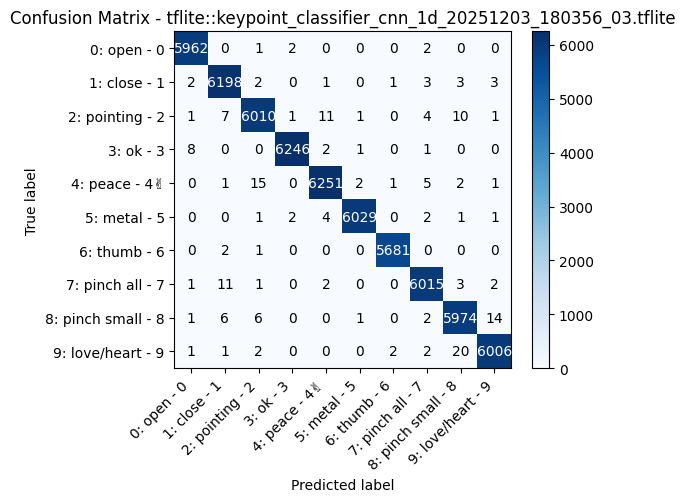

C:\Users\brian\AppData\Local\Temp\ipykernel_24580\1998907906.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


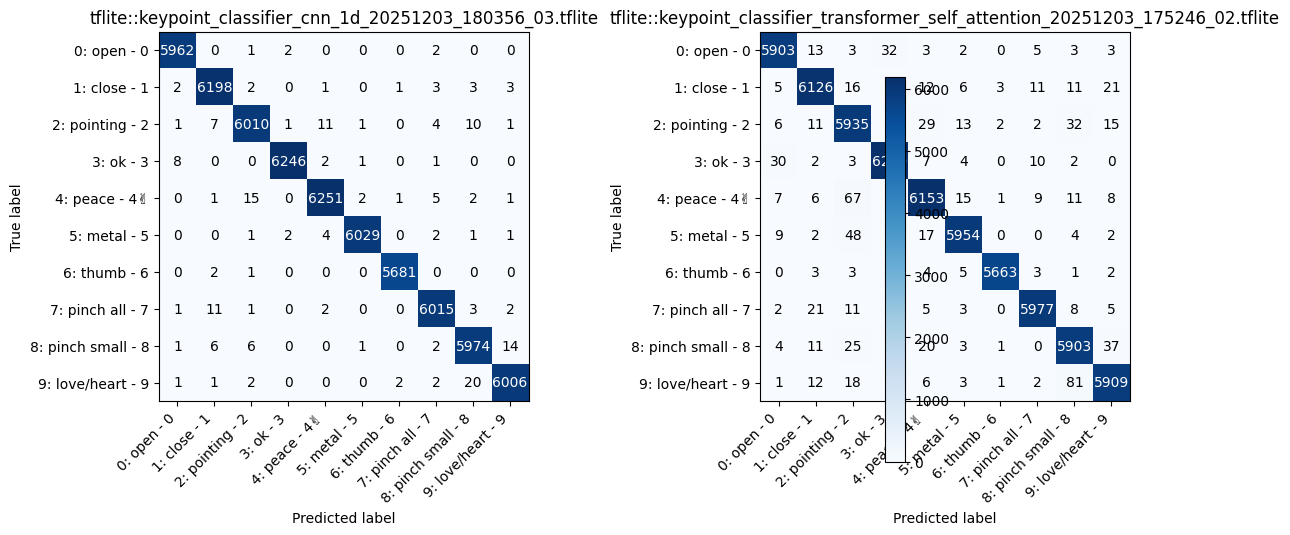

In [47]:
model_a = summary_df["model_name"].iloc[0]
model_b = summary_df["model_name"].iloc[2] if len(summary_df) > 1 else None

print(f"Model A: {model_a}")
print(f"Model B: {model_b}")

res_a = all_results[model_a]
plot_confusion_matrix(res_a["cm"], res_a["label_strings"], title=f"Confusion Matrix - {model_a}")

if model_b is not None:
    res_b = all_results[model_b]
    if np.array_equal(res_a["labels"], res_b["labels"]):
        plot_two_confusion_matrices(
            cm_a=res_a["cm"],
            labels_a=res_a["label_strings"],
            name_a=model_a,
            cm_b=res_b["cm"],
            labels_b=res_b["label_strings"],
            name_b=model_b,
        )
    else:
        print("Labels differ, skip side-by-side comparison.")


In [38]:
best_model_name = summary_df["model_name"].iloc[0]
y_true = all_results[best_model_name]["y_true"]
y_best = all_results[best_model_name]["y_pred"]

rows = []
for name, res in all_results.items():
    if name == best_model_name:
        continue
    y_pred = res["y_pred"]
    chi2_stat, p_value, b, c = mcnemars_test(y_true, y_best, y_pred)
    rows.append({
        "model_name": name,
        "vs_best_model": best_model_name,
        "chi2_stat": chi2_stat,
        "p_value": p_value,
        "b_best_correct_other_wrong": b,
        "c_best_wrong_other_correct": c,
        "significant_at_0.05": (p_value < 0.05) if not np.isnan(p_value) else np.nan,
    })

if rows:
    mcnemar_df = pd.DataFrame(rows).sort_values("p_value")
    print("McNemar's test (difference vs best model):")
    display(mcnemar_df)
else:
    print("Only one model available — McNemar's test needs at least two.")


McNemar's test (difference vs best model):


,model_name,vs_best_model,chi2_stat,p_value,b_best_correct_other_wrong,c_best_wrong_other_correct,significant_at_0.05
1,tflite::keypoint_classifier_mlp_20251203_171400_01.tflite,tflite::keypoint_classifier_cnn_1d_20251203_180356_03.tflite,23240.369205,0.000000e+00,23380,46,True
2,tflite::keypoint_classifier_transformer_self_attention_20251203_175246_02.tflite,tflite::keypoint_classifier_cnn_1d_20251203_180356_03.tflite,534.909554,2.414671e-118,717,68,True
0,joblib::keypoint_classifier_kneighbors_20251203_171329_00.joblib,tflite::keypoint_classifier_cnn_1d_20251203_180356_03.tflite,156.568182,6.360756e-36,323,73,True


In [39]:
if GESTURE_GROUPS:
    for group_name, group_ids in GESTURE_GROUPS.items():
        focus_labels = [label_map.get(i, str(i)) for i in group_ids]
        print(f"\n--- Analysis for {group_name}: {group_ids} -> {focus_labels} ---")

        res = all_results[summary_df["model_name"].iloc[0]]
        mask = np.isin(res["y_true"], group_ids)
        if mask.sum() == 0:
            print("No samples from this group in the dataset.")
            continue

        sim_df = pd.DataFrame({
            "true_id": res["y_true"][mask],
            "pred_id": res["y_pred"][mask],
        })
        sim_df["true_label"] = sim_df["true_id"].map(label_map)
        sim_df["pred_label"] = sim_df["pred_id"].map(label_map)

        pivot_counts = pd.crosstab(sim_df["true_label"], sim_df["pred_label"], dropna=False)
        pivot_rates = pivot_counts.div(pivot_counts.sum(axis=1), axis=0).fillna(0.0)

        print("Counts within group:")
        display(pivot_counts)

        print("Row-normalized confusion (fractions):")
        display(pivot_rates)
else:
    print("No gesture groups configured.")



--- Analysis for Cluster A: [3, 7, 8, 9] -> ['ok - 3', 'pinch all - 7', 'pinch small - 8', 'love/heart - 9'] ---
Counts within group:


pred_label,close - 1,love/heart - 9,metal - 5,ok - 3,open - 0,peace - 4✌,pinch all - 7,pinch small - 8,pointing - 2,thumb - 6
true_label,,,,,,,,,,
love/heart - 9,1,6006,0,0,1,0,2,20,2,2
ok - 3,0,0,1,6246,8,2,1,0,0,0
pinch all - 7,11,2,0,0,1,2,6015,3,1,0
pinch small - 8,6,14,1,0,1,0,2,5974,6,0


Row-normalized confusion (fractions):


pred_label,close - 1,love/heart - 9,metal - 5,ok - 3,open - 0,peace - 4✌,pinch all - 7,pinch small - 8,pointing - 2,thumb - 6
true_label,,,,,,,,,,
love/heart - 9,0.000166,0.995360,0.000000,0.000000,0.000166,0.000000,0.000331,0.003315,0.000331,0.000331
ok - 3,0.000000,0.000000,0.000160,0.998082,0.001278,0.000320,0.000160,0.000000,0.000000,0.000000
pinch all - 7,0.001823,0.000331,0.000000,0.000000,0.000166,0.000331,0.996686,0.000497,0.000166,0.000000
pinch small - 8,0.000999,0.002332,0.000167,0.000000,0.000167,0.000000,0.000333,0.995003,0.000999,0.000000



--- Analysis for Cluster B: [2, 4, 5, 6] -> ['pointing - 2', 'peace - 4✌', 'metal - 5', 'thumb - 6'] ---
Counts within group:


pred_label,close - 1,love/heart - 9,metal - 5,ok - 3,open - 0,peace - 4✌,pinch all - 7,pinch small - 8,pointing - 2,thumb - 6
true_label,,,,,,,,,,
metal - 5,0,1,6029,2,0,4,2,1,1,0
peace - 4✌,1,1,2,0,0,6251,5,2,15,1
pointing - 2,7,1,1,1,1,11,4,10,6010,0
thumb - 6,2,0,0,0,0,0,0,0,1,5681


Row-normalized confusion (fractions):


pred_label,close - 1,love/heart - 9,metal - 5,ok - 3,open - 0,peace - 4✌,pinch all - 7,pinch small - 8,pointing - 2,thumb - 6
true_label,,,,,,,,,,
metal - 5,0.000000,0.000166,0.998179,0.000331,0.000000,0.000662,0.000331,0.000166,0.000166,0.000000
peace - 4✌,0.000159,0.000159,0.000319,0.000000,0.000000,0.995699,0.000796,0.000319,0.002389,0.000159
pointing - 2,0.001158,0.000165,0.000165,0.000165,0.000165,0.001819,0.000662,0.001654,0.994046,0.000000
thumb - 6,0.000352,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000176,0.999472


Calculating ROC for 1D CNN...
Loading 1D CNN from ../models/keypoint/keypoint_classifier_cnn_1d.tflite


c:\Users\brian\Documents\GitHub\mediapipe-hand-recognition\.conda\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


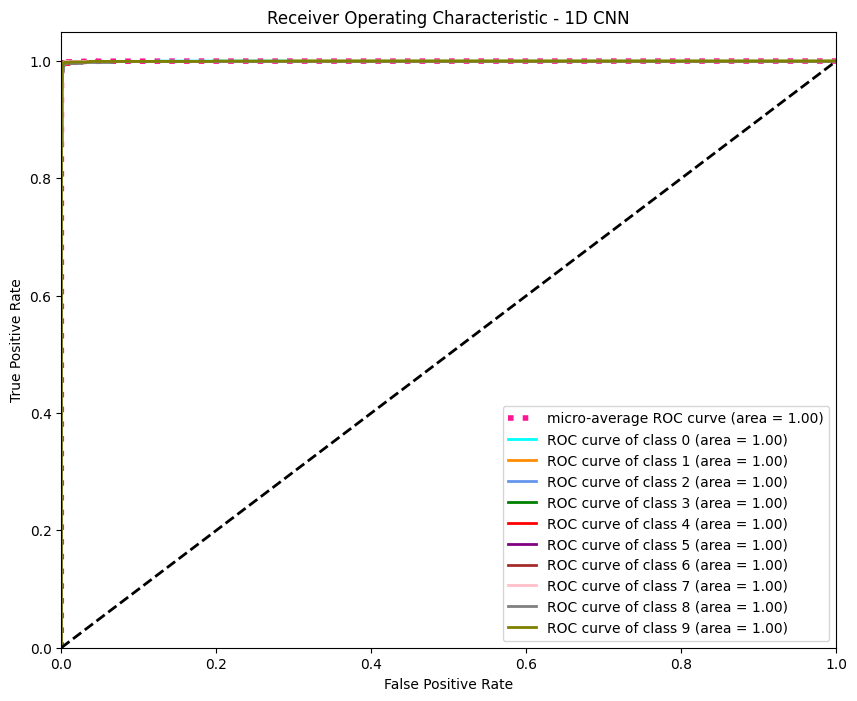

In [48]:
# ROC-AUC Analysis for KNN and Graph Transformer
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle
import numpy as np
import matplotlib.pyplot as plt
import joblib
import tensorflow as tf

def plot_roc_auc(y_test, y_score, model_name, n_classes):
    # Handle shape mismatch if y_score has fewer columns than n_classes
    if y_score.shape[1] < n_classes:
        print(f"Note: {model_name} output shape {y_score.shape} < n_classes {n_classes}. Padding with zeros.")
        y_score_padded = np.zeros((y_score.shape[0], n_classes))
        y_score_padded[:, :y_score.shape[1]] = y_score
        y_score = y_score_padded

    # Binarize the output
    y_test_bin = label_binarize(y_test, classes=range(n_classes))

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    # Compute ROC curve and ROC area for each class
    for i in range(n_classes):
        if np.sum(y_test_bin[:, i]) == 0:
             fpr[i], tpr[i], roc_auc[i] = [0], [0], 0.0
             continue
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Compute micro-average ROC curve and ROC area
    fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    # Plot ROC curve
    plt.figure(figsize=(10, 8))
    plt.plot(fpr["micro"], tpr["micro"],
             label='micro-average ROC curve (area = {0:0.2f})'
                   ''.format(roc_auc["micro"]),
             color='deeppink', linestyle=':', linewidth=4)

    colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple', 'brown', 'pink', 'gray', 'olive'])
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label='ROC curve of class {0} (area = {1:0.2f})'
                 ''.format(i, roc_auc[i]))

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic - {model_name}')
    plt.legend(loc="lower right")
    plt.show()

# 1. Prepare Data
X_test_roc = X_val_split
y_test_roc = y_val_split
n_classes = NUM_CLASSES

# 2. ROC
print("Calculating ROC for 1D CNN...")
gt_path = "../models/keypoint/keypoint_classifier_cnn_1d.tflite"

if gt_path:
    print(f"Loading 1D CNN from {gt_path}")
    interpreter = tf.lite.Interpreter(model_path=str(gt_path))
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    input_info = input_details[0]
    output_info = output_details[0]
    input_idx = input_info['index']
    output_idx = output_info['index']

    input_shape = list(input_info.get("shape_signature", input_info["shape"]))
    if input_shape[0] == -1:
        input_shape[0] = 1  # replace dynamic batch dim for reshaping
    input_dtype = input_info["dtype"]

    def prepare_inputs(X_raw):
        if len(input_shape) == 3:
            steps, channels = input_shape[1], input_shape[2]
            expected_features = steps * channels
            if X_raw.shape[1] != expected_features:
                raise ValueError(f"Expected {expected_features} features for ROC eval but got {X_raw.shape[1]}")
            return X_raw.reshape(-1, steps, channels).astype(input_dtype)
        return X_raw.astype(input_dtype)

    X_test_prepared = prepare_inputs(X_test_roc)

    y_score_gt = []
    for i in range(len(X_test_prepared)):
        inp = np.expand_dims(X_test_prepared[i], axis=0)
        interpreter.set_tensor(input_idx, inp)
        interpreter.invoke()
        out = interpreter.get_tensor(output_idx)
        y_score_gt.append(out[0])

    y_score_gt = np.array(y_score_gt)
    plot_roc_auc(y_test_roc, y_score_gt, "1D CNN", n_classes)
else:
    print("1D CNN model not found.")
